In [1]:
# Libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from textblob import TextBlob

/var/folders/b5/b_hjq21d67lgp0npg6xs3bmm0000gn/T/ipykernel_2820/104618519.py:2: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [2]:
# Retrieving all the articles
articles_df = pd.read_csv('articles_combined.csv')
articles_df['date'] = pd.to_datetime(articles_df['date'])

# Generating the sentiment for each text articles
sentiments = []

for articles in articles_df['article_text']:
    polarity = TextBlob(articles).sentiment.polarity
    sentiments.append(polarity)
    
# Appending polarity to dataframe
articles_df['polarity'] = sentiments

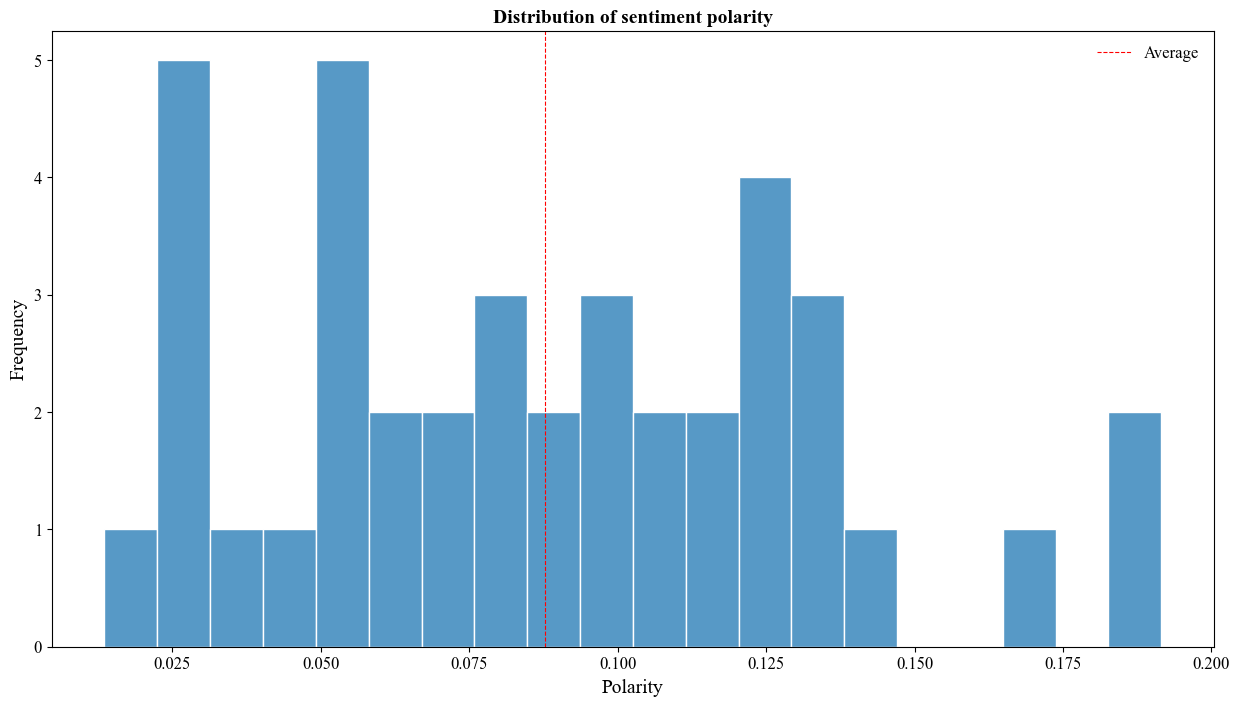

In [3]:
# Distribution of the polarity
plt.rcParams['font.family'] = 'Times New Roman'

plt.figure(figsize = (15, 8))
sns.histplot(articles_df['polarity'], bins=20, edgecolor='white')
plt.axvline(np.mean(articles_df['polarity']), color='red', linestyle='--', label='Average', linewidth = 0.8)
plt.ylabel('Frequency', size = 14)
plt.xlabel('Polarity', size = 14)
plt.xticks(size = 12)
plt.yticks(size = 12)
plt.title('Distribution of sentiment polarity', weight = 'bold', size = 14)
plt.legend(frameon = False, prop = {'size': 12})
plt.show()

In [7]:
articles_df['polarity'].min(), articles_df['polarity'].max(), articles_df['polarity'].median()

(0.013607450943217369, 0.19155582922824302, 0.0846813943109526)

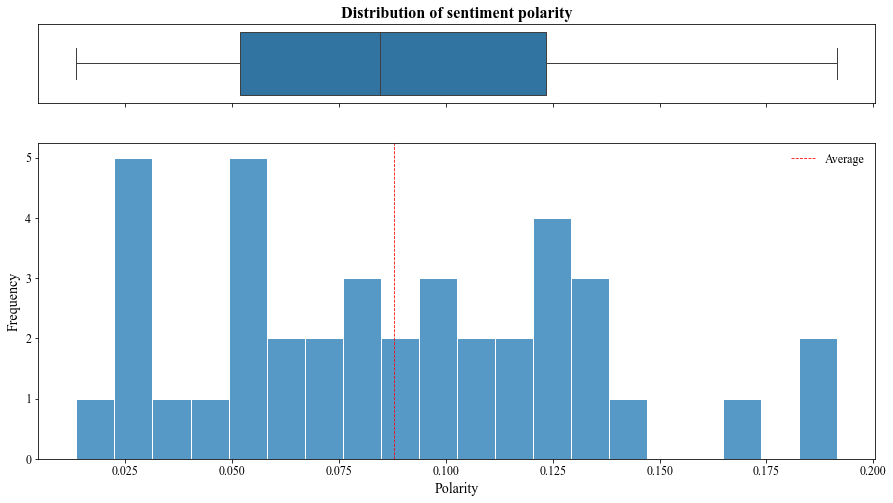

In [133]:
plt.rcParams['font.family'] = 'Times New Roman'

# Create figure with shared x-axis
fig, (ax_box, ax_hist) = plt.subplots(
    2, 1, 
    figsize=(15, 8), 
    gridspec_kw={'height_ratios': [0.2, 0.8]}, 
    sharex=True
)

# Boxplot (top)
sns.boxplot(x=articles_df['polarity'], ax=ax_box,)
ax_box.set(xlabel='', yticks=[])
ax_box.set_title('Distribution of sentiment polarity', weight='bold', size=16)

# Histogram (bottom)
sns.histplot(articles_df['polarity'], bins=20, edgecolor='white', ax=ax_hist)
ax_hist.axvline(np.mean(articles_df['polarity']), color='red', linestyle='--', label='Average', linewidth=0.8)
ax_hist.set_ylabel('Frequency', size=14)
ax_hist.set_xlabel('Polarity', size=14)
ax_hist.tick_params(axis='x', labelsize=12)
ax_hist.tick_params(axis='y', labelsize=12)
ax_hist.legend(frameon=False, prop={'size': 12})

plt.show()

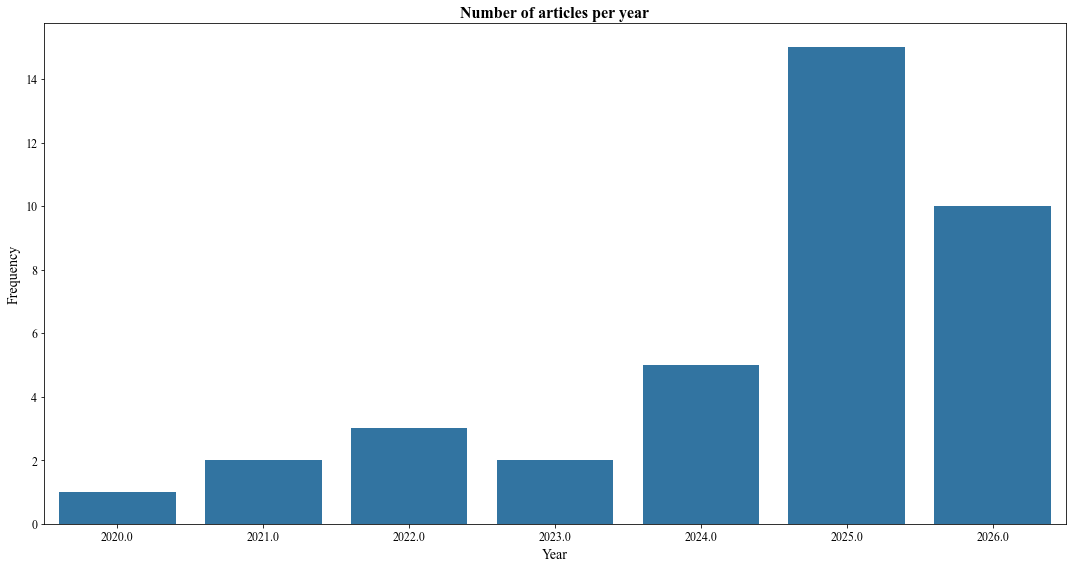

In [170]:
# Number of articles per year
x = articles_df['date'].dt.year.value_counts().index
y = articles_df['date'].dt.year.value_counts().values

plt.rcParams['font.family'] = 'Times New Roman'
plt.figure(figsize = (15, 8))
sns.barplot(x = x, y = y)
plt.ylabel('Frequency', size = 14)
plt.xlabel('Year', size = 14)
plt.yticks(size = 12)
plt.xticks(size = 12)
plt.title('Number of articles per year', size = 16, weight = 'bold')
plt.tight_layout()
plt.show()

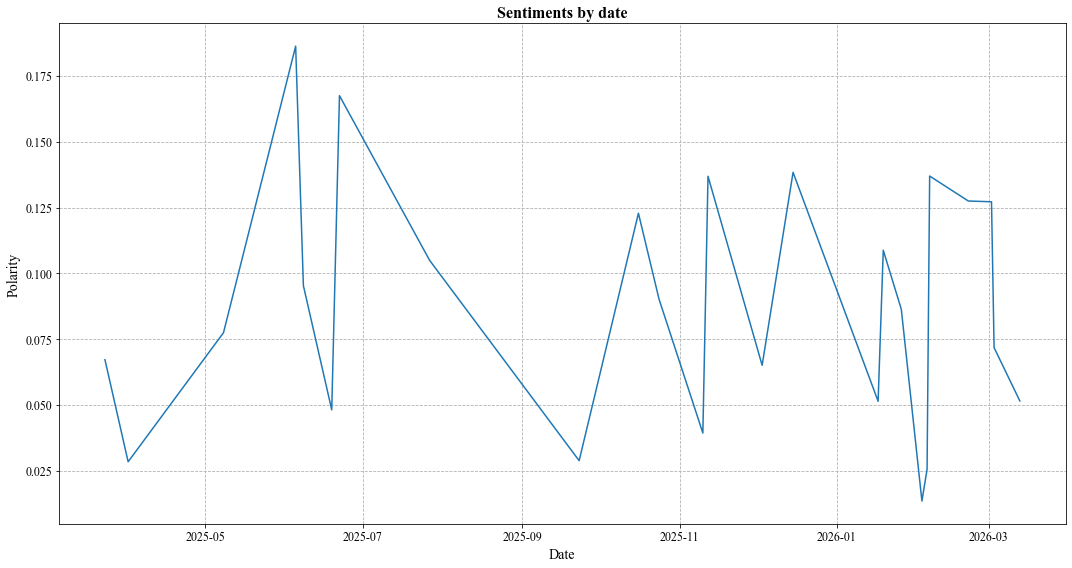

In [171]:
# Trend 

plt.rcParams['font.family'] = 'Times New Roman'

plt.figure(figsize = (15, 8))
plt.title('Sentiments by date', size = 16, weight = 'bold')
sns.lineplot(x = articles_df['date'][articles_df['date'].dt.year >= 2025], 
             y = articles_df['polarity'][articles_df['date'].dt.year >= 2025])
plt.xlabel('Date', size = 14)
plt.ylabel('Polarity', size = 14)
plt.xticks(size = 12)
plt.yticks(size = 12)
plt.grid(linestyle = '--', linewidth = 0.8)
plt.tight_layout()
plt.show()

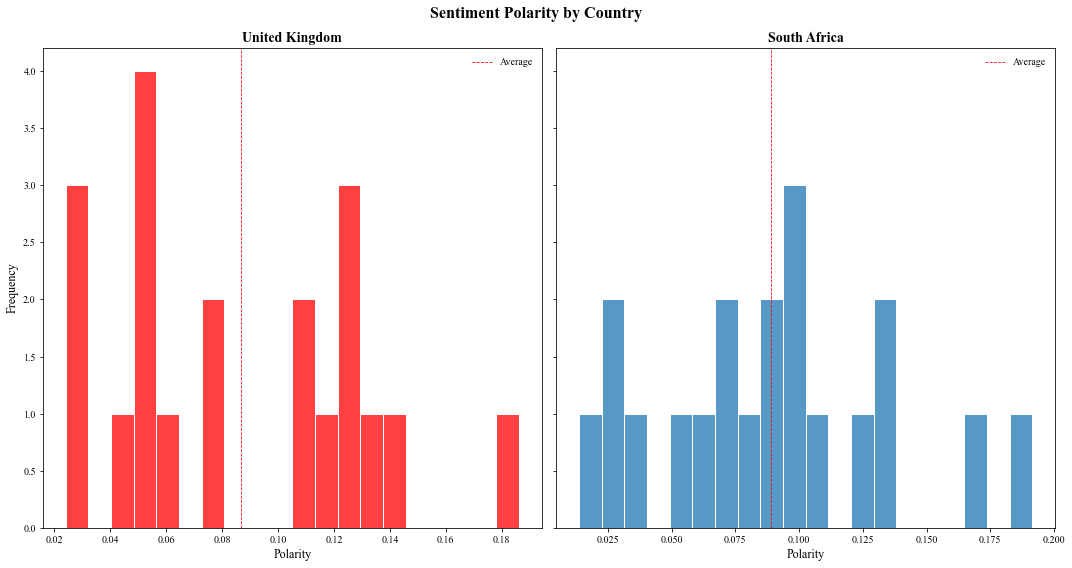

In [172]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.family'] = 'Times New Roman'

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(15, 8), sharey=True)

# United Kingdom
sns.histplot(
    articles_df['polarity'][articles_df['country'] == 'United Kingdom'],
    bins=20, edgecolor='white', ax=axes[0], color = 'red'
)
axes[0].axvline(
    articles_df['polarity'][articles_df['country'] == 'United Kingdom'].mean(),
    color='red', linestyle='--', linewidth=0.8, label='Average'
)
axes[0].set_title('United Kingdom', weight='bold', size=14)
axes[0].set_xlabel('Polarity', size=12)
axes[0].set_ylabel('Frequency', size=12)
axes[0].legend(frameon=False, prop={'size': 10})

# South Africa
sns.histplot(
    articles_df['polarity'][articles_df['country'] == 'South Africa'],
    bins=20, edgecolor='white', ax=axes[1]
)
axes[1].axvline(
    articles_df['polarity'][articles_df['country'] == 'South Africa'].mean(),
    color='red', linestyle='--', linewidth=0.8, label='Average'
)
axes[1].set_title('South Africa', weight='bold', size=14)
axes[1].set_xlabel('Polarity', size=12)
axes[1].set_ylabel('Frequency', size=12)
axes[1].legend(frameon=False, prop={'size': 10})

plt.suptitle('Sentiment Polarity by Country', weight='bold', size=16)
plt.tight_layout()
plt.show()

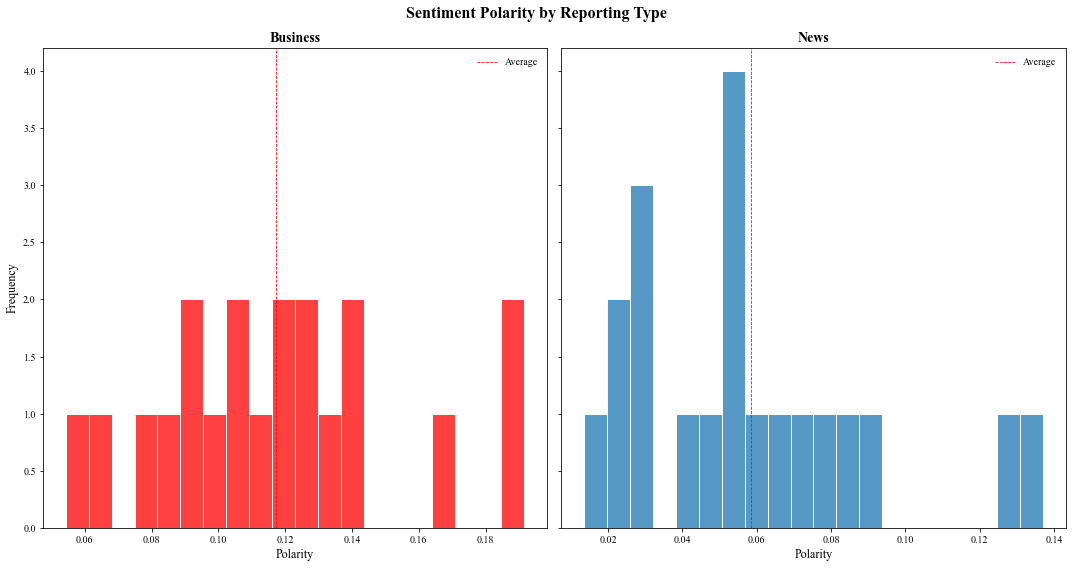

In [173]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.family'] = 'Times New Roman'

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(15, 8), sharey=True)

# United Kingdom
sns.histplot(
    articles_df['polarity'][articles_df['reporting style'] == 'Business'],
    bins=20, edgecolor='white', ax=axes[0], color = 'red'
)
axes[0].axvline(
    articles_df['polarity'][articles_df['reporting style'] == 'Business'].mean(),
    color='red', linestyle='--', linewidth=0.8, label='Average'
)
axes[0].set_title('Business', weight='bold', size=14)
axes[0].set_xlabel('Polarity', size=12)
axes[0].set_ylabel('Frequency', size=12)
axes[0].legend(frameon=False, prop={'size': 10})

# South Africa
sns.histplot(
    articles_df['polarity'][articles_df['reporting style'] == 'News'],
    bins=20, edgecolor='white', ax=axes[1]
)
axes[1].axvline(
    articles_df['polarity'][articles_df['reporting style'] == 'News'].mean(),
    color='red', linestyle='--', linewidth=0.8, label='Average'
)
axes[1].set_title('News', weight='bold', size=14)
axes[1].set_xlabel('Polarity', size=12)
axes[1].set_ylabel('Frequency', size=12)
axes[1].legend(frameon=False, prop={'size': 10})

plt.suptitle('Sentiment Polarity by Reporting Type', weight='bold', size=16)
plt.tight_layout()
plt.show()